# Random Forest Model for Movie Rating Prediction

This notebook builds and evaluates a Random Forest model to predict movie ratings (`avg_rating`) based on the engineered features. Random Forest is an ensemble method that can capture non-linear relationships and interactions between features.

## Contents
1. Load Data and Configuration
2. Data Preparation and Train-Test Split
3. Train Random Forest Model
4. Model Evaluation
5. Visualize Predictions
6. Feature Importance Analysis
7. Save the Model

## 1. Load Data and Configuration

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import joblib
from datetime import datetime
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the processed features
features_df = pd.read_csv('../data/processed_movie_features.csv')

print(f"Dataset shape: {features_df.shape}")
print(f"\nFirst few rows:")
features_df.head()

Dataset shape: (138032, 93)

First few rows:


,movieId,title,avg_rating,runtime,genre_Action,genre_Adult,genre_Adventure,genre_Animation,genre_Biography,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_Film-Noir,genre_Game-Show,genre_History,genre_Horror,genre_Music,genre_Musical,genre_Mystery,genre_News,genre_Reality-TV,genre_Romance,genre_Sci-Fi,genre_Sport,genre_Talk-Show,genre_Thriller,genre_War,genre_Western,genre_count,director_top01,director_top02,director_top03,director_top04,director_top05,director_top06,director_top07,director_top08,director_top09,director_top10,director_top11,director_top12,director_top13,director_top14,director_top15,director_top16,director_top17,director_top18,director_top19,director_top20,writer_top01,writer_top02,writer_top03,writer_top04,writer_top05,writer_top06,writer_top07,writer_top08,writer_top09,writer_top10,writer_top11,writer_top12,writer_top13,writer_top14,writer_top15,writer_top16,writer_top17,writer_top18,writer_top19,writer_top20,actor_top01,actor_top02,actor_top03,actor_top04,actor_top05,actor_top06,actor_top07,actor_top08,actor_top09,actor_top10,actor_top11,actor_top12,actor_top13,actor_top14,actor_top15,actor_top16,actor_top17,actor_top18,actor_top19,actor_top20,is_auteur_film
0,tt0000574,The Story of the Kelly Gang,6.000,70.000,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,tt0001892,Den sorte drøm,5.800,53.000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,tt0001964,The Traitress,5.800,48.000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,tt0002101,Cleopatra,5.100,100.000,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,tt0002130,Dante's Inferno,7.000,71.000,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# Load feature configuration
with open('../data/feature_info.json', 'r') as f:
    feature_info = json.load(f)

# Extract feature columns and target variable
feature_columns = feature_info['feature_columns']
target_variable = feature_info['target_variable']

print(f"Target variable: {target_variable}")
print(f"Number of features: {len(feature_columns)}")
print(f"\nFeature columns (first 10): {feature_columns[:10]}")

Target variable: avg_rating
Number of features: 90

Feature columns (first 10): ['runtime', 'genre_Action', 'genre_Adult', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama']


## 2. Data Preparation and Train-Test Split

In [4]:
# Prepare X (features) and y (target)
X = features_df[feature_columns]
y = features_df[target_variable]

# Check for missing values
print(f"Missing values in X: {X.isna().sum().sum()}")
print(f"Missing values in y: {y.isna().sum()}")

# Remove any rows with missing values
mask = ~(X.isna().any(axis=1) | y.isna())
X_clean = X[mask]
y_clean = y[mask]

print(f"\nOriginal dataset size: {len(features_df)}")
print(f"Clean dataset size: {len(X_clean)}")
print(f"Removed rows: {len(features_df) - len(X_clean)}")

Missing values in X: 0
Missing values in y: 0

Original dataset size: 138032
Clean dataset size: 138032
Removed rows: 0


In [5]:
# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTarget variable statistics:")
print(f"Train - Mean: {y_train.mean():.3f}, Std: {y_train.std():.3f}, Min: {y_train.min():.3f}, Max: {y_train.max():.3f}")
print(f"Test  - Mean: {y_test.mean():.3f}, Std: {y_test.std():.3f}, Min: {y_test.min():.3f}, Max: {y_test.max():.3f}")

Training set size: 110425
Test set size: 27607

Target variable statistics:
Train - Mean: 5.910, Std: 1.272, Min: 1.000, Max: 9.900
Test  - Mean: 5.928, Std: 1.263, Min: 1.000, Max: 9.900


## 3. Train Random Forest Model

In [6]:
# Initialize and train the Random Forest model
print("Training Random Forest model...")
import time
start_time = time.time()

# Initialize Random Forest with optimized parameters
rf_model = RandomForestRegressor(
    n_estimators=100,        # Number of trees
    max_depth=10,           # Maximum depth to prevent overfitting
    min_samples_split=5,    # Minimum samples to split a node
    min_samples_leaf=2,     # Minimum samples in a leaf
    random_state=42,        # For reproducibility
    n_jobs=-1              # Use all available cores
)

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"✓ Training completed in {training_time:.2f} seconds")

# Make predictions on both train and test sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("✓ Predictions generated successfully!")

Training Random Forest model...
✓ Training completed in 4.41 seconds
✓ Predictions generated successfully!
✓ Training completed in 4.41 seconds
✓ Predictions generated successfully!


## 4. Model Evaluation

In [7]:
# Calculate evaluation metrics
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Set Performance:")
    print(f"{'='*50}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"MAE (Mean Absolute Error):      {mae:.4f}")
    print(f"R² Score:                       {r2:.4f}")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Evaluate on training set
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test set
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Check for overfitting
print(f"\n{'='*50}")
print("Overfitting Analysis:")
print(f"Train R² - Test R²: {train_metrics['r2'] - test_metrics['r2']:.4f}")
if abs(train_metrics['r2'] - test_metrics['r2']) < 0.05:
    print("✓ Model generalizes well (low overfitting)")
else:
    print("⚠ Potential overfitting detected")

# Additional Random Forest specific metrics
print(f"\nRandom Forest Model Details:")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Maximum depth: {rf_model.max_depth}")
print(f"Out-of-bag score: {rf_model.oob_score_:.4f}" if hasattr(rf_model, 'oob_score_') else "OOB score not available")


Training Set Performance:
RMSE (Root Mean Squared Error): 1.0357
MAE (Mean Absolute Error):      0.7890
R² Score:                       0.3375

Test Set Performance:
RMSE (Root Mean Squared Error): 1.0364
MAE (Mean Absolute Error):      0.7910
R² Score:                       0.3271

Overfitting Analysis:
Train R² - Test R²: 0.0103
✓ Model generalizes well (low overfitting)

Random Forest Model Details:
Number of trees: 100
Maximum depth: 10
OOB score not available


## 5. Visualize Predictions

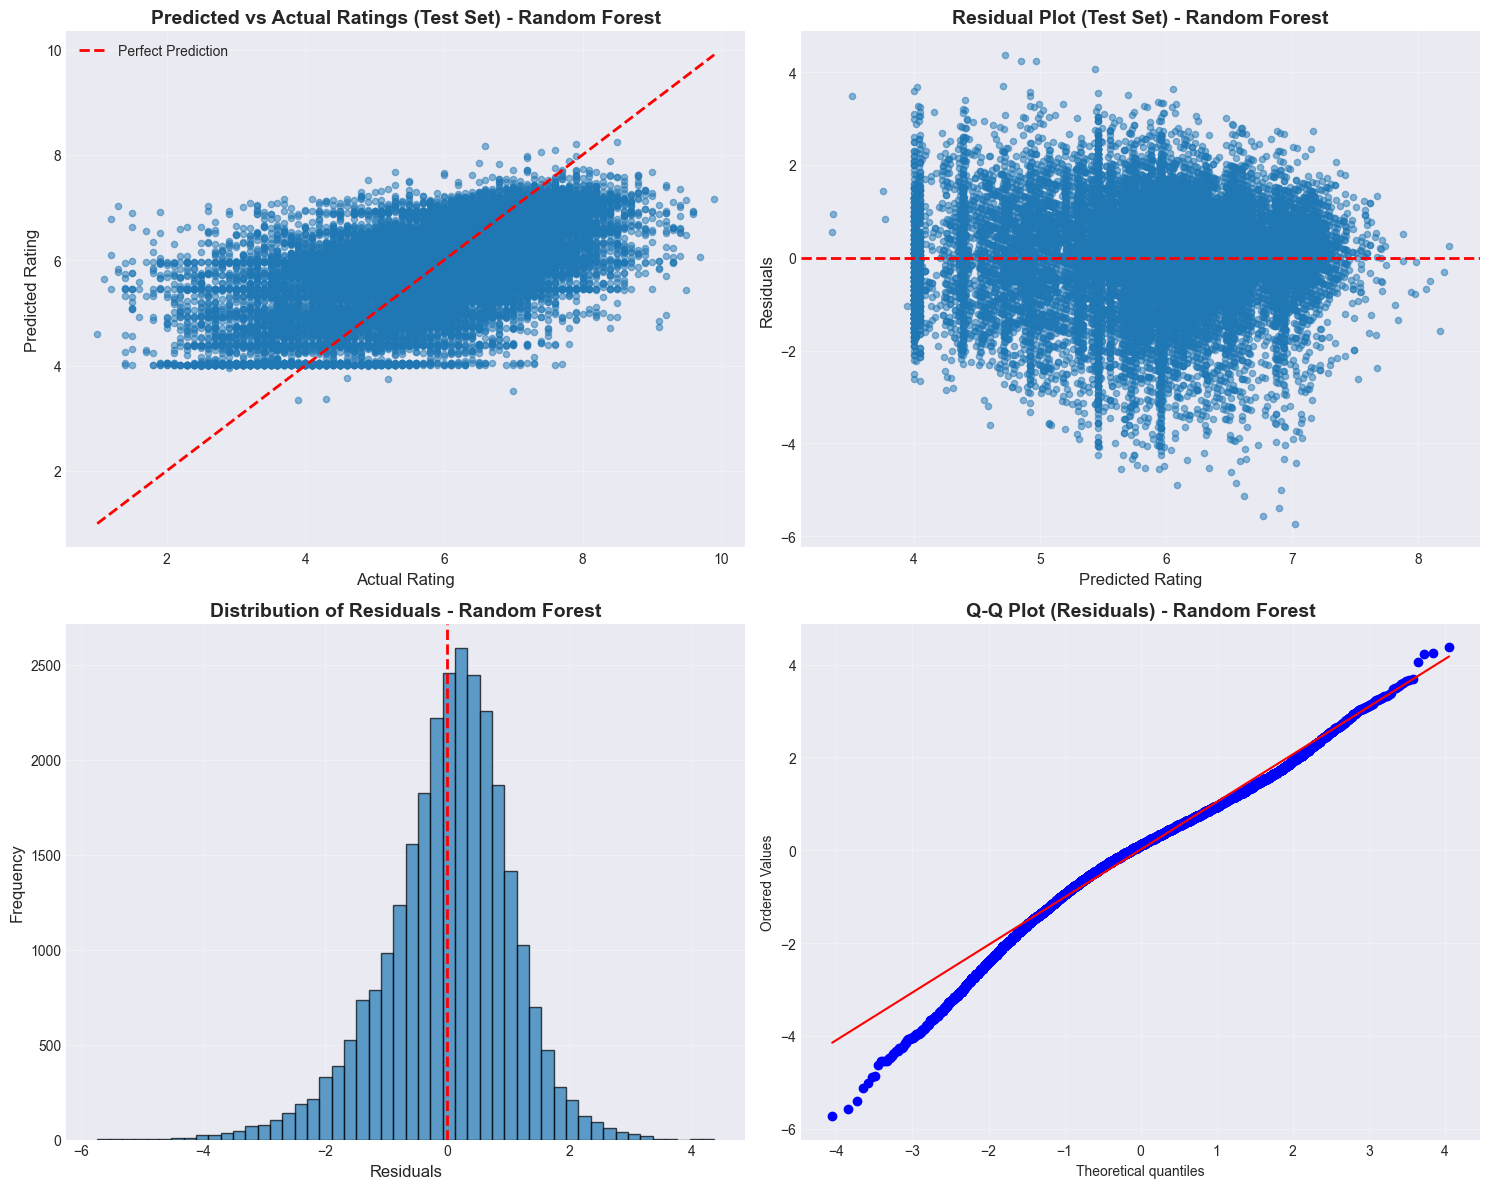


Residual Statistics:
Mean: 0.0161
Std: 1.0363
Min: -5.7279
Max: 4.3742


In [8]:
# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicted vs Actual (Test Set)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Rating', fontsize=12)
axes[0, 0].set_ylabel('Predicted Rating', fontsize=12)
axes[0, 0].set_title('Predicted vs Actual Ratings (Test Set) - Random Forest', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual Plot (Test Set)
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Rating', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title('Residual Plot (Test Set) - Random Forest', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Residuals
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals - Random Forest', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q Plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Residuals) - Random Forest', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"Mean: {residuals.mean():.4f}")
print(f"Std: {residuals.std():.4f}")
print(f"Min: {residuals.min():.4f}")
print(f"Max: {residuals.max():.4f}")

## 6. Feature Importance Analysis

In [9]:
# Load people mapping for better readability
with open('../data/top_people_mapping.json', 'r') as f:
    people_mapping = json.load(f)

# Create a mapping dictionary for all people features
feature_name_mapping = {}

# Map directors
for key, value in people_mapping['directors'].items():
    feature_name_mapping[key] = f"{key.replace('_', ' ').title()} ({value['name']})"

# Map writers
for key, value in people_mapping['writers'].items():
    feature_name_mapping[key] = f"{key.replace('_', ' ').title()} ({value['name']})"

# Map actors
for key, value in people_mapping['actors'].items():
    feature_name_mapping[key] = f"{key.replace('_', ' ').title()} ({value['name']})"

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
})

# Add readable names
feature_importance['readable_name'] = feature_importance['feature'].apply(
    lambda x: feature_name_mapping.get(x, x.replace('_', ' ').title())
)

# Sort by importance
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Display top 20 most important features
print("Top 20 Most Important Features (Random Forest Feature Importance):")
print("="*80)
for idx, row in feature_importance.head(20).iterrows():
    print(f"{row['readable_name']:50s} {row['importance']:8.4f}")

# Calculate cumulative importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
print(f"\nTop 10 features account for {feature_importance.head(10)['cumulative_importance'].iloc[-1]:.1%} of total importance")
print(f"Top 20 features account for {feature_importance.head(20)['cumulative_importance'].iloc[-1]:.1%} of total importance")

Top 20 Most Important Features (Random Forest Feature Importance):
Genre Horror                                         0.3181
Runtime                                              0.1939
Genre Documentary                                    0.1683
Genre Drama                                          0.1127
Is Auteur Film                                       0.0544
Genre Action                                         0.0355
Genre Thriller                                       0.0245
Genre Sci-Fi                                         0.0220
Genre Animation                                      0.0208
Genre Comedy                                         0.0106
Genre Crime                                          0.0083
Genre Mystery                                        0.0057
Genre Fantasy                                        0.0035
Genre Biography                                      0.0033
Genre Romance                                        0.0032
Genre Musical                    

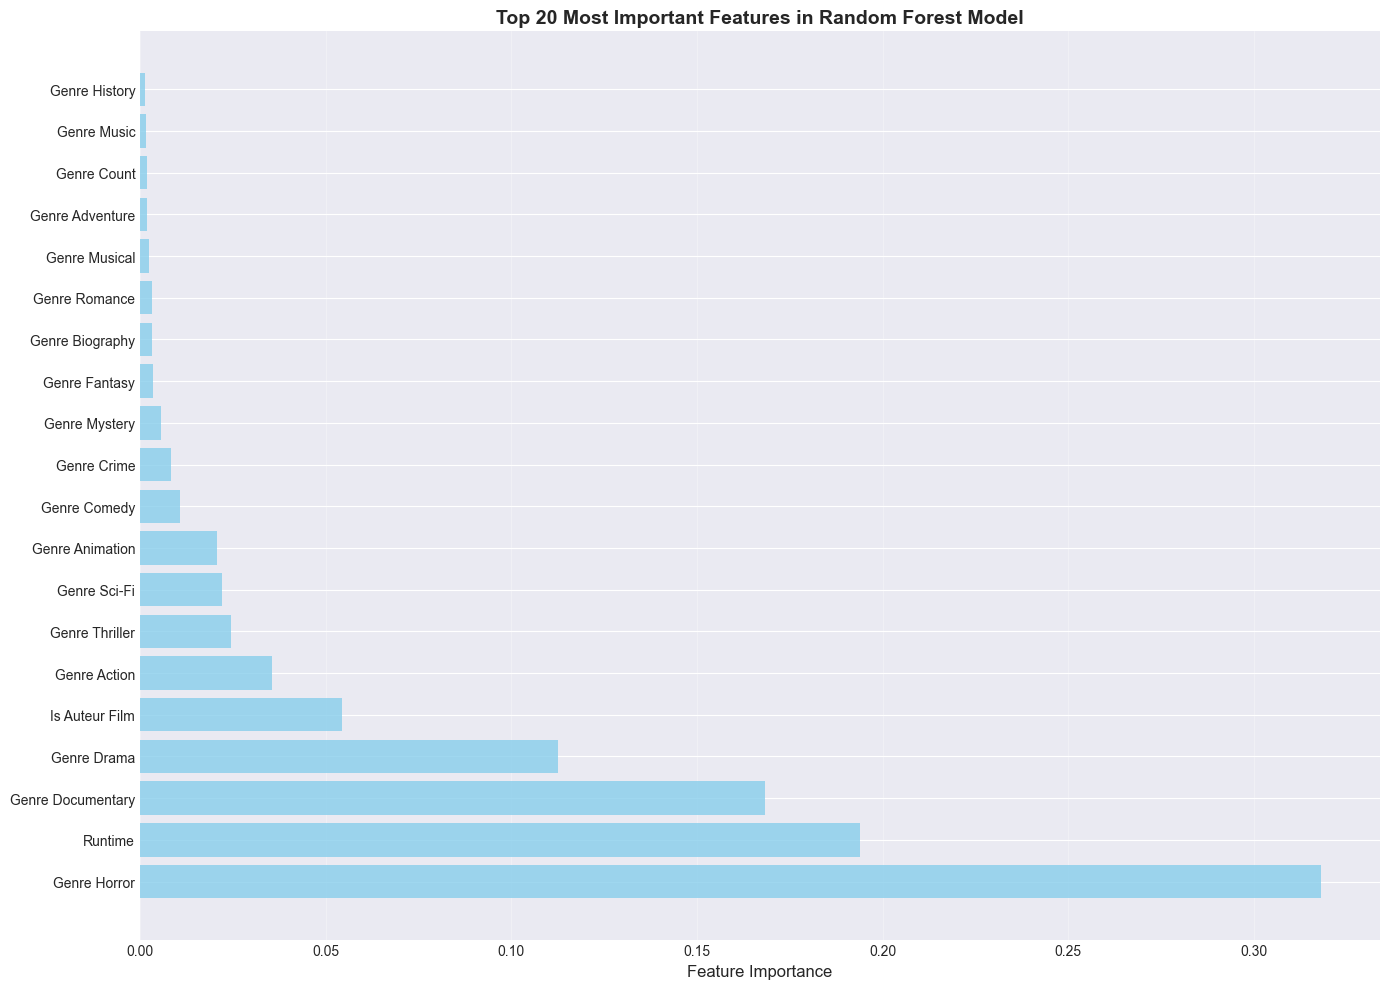

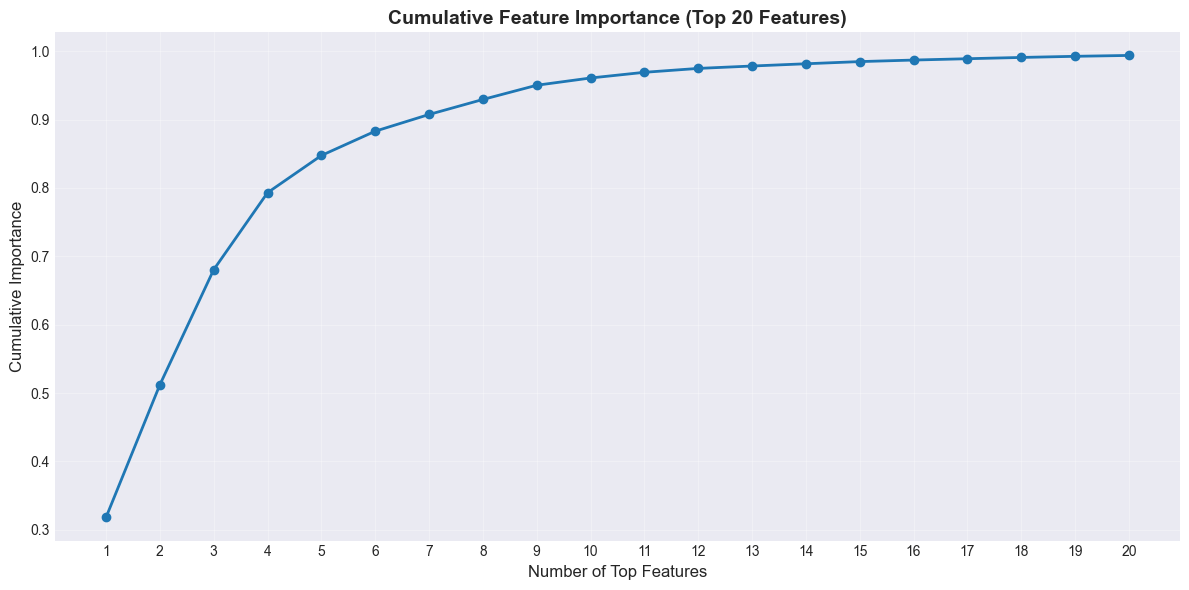

In [10]:
# Visualize top 20 features
plt.figure(figsize=(14, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='skyblue', alpha=0.8)
plt.yticks(range(len(top_features)), top_features['readable_name'], fontsize=10)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 20 Most Important Features in Random Forest Model', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Plot cumulative importance
plt.figure(figsize=(12, 6))
plt.plot(range(1, 21), feature_importance.head(20)['cumulative_importance'], 
         marker='o', linewidth=2, markersize=6)
plt.xlabel('Number of Top Features', fontsize=12)
plt.ylabel('Cumulative Importance', fontsize=12)
plt.title('Cumulative Feature Importance (Top 20 Features)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

## 7. Save the Model

In [11]:
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the trained model
model_path = '../models/random_forest_model.pkl'
joblib.dump(rf_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save model metadata
model_metadata = {
    'model_type': 'RandomForestRegressor',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_columns),
    'feature_columns': feature_columns,
    'target_variable': target_variable,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'hyperparameters': {
        'n_estimators': rf_model.n_estimators,
        'max_depth': rf_model.max_depth,
        'min_samples_split': rf_model.min_samples_split,
        'min_samples_leaf': rf_model.min_samples_leaf,
        'random_state': rf_model.random_state
    },
    'performance_metrics': {
        'train': {
            'rmse': float(train_metrics['rmse']),
            'mae': float(train_metrics['mae']),
            'r2': float(train_metrics['r2'])
        },
        'test': {
            'rmse': float(test_metrics['rmse']),
            'mae': float(test_metrics['mae']),
            'r2': float(test_metrics['r2'])
        }
    },
    'top_10_features': feature_importance.head(10)[['feature', 'importance']].to_dict('records')
}

metadata_path = '../models/random_forest_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✓ Model metadata saved to: {metadata_path}")

print("\n" + "="*70)
print("RANDOM FOREST MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)
print(f"\nModel Summary:")
print(f"  - Training samples: {len(X_train):,}")
print(f"  - Test samples: {len(X_test):,}")
print(f"  - Features: {len(feature_columns)}")
print(f"  - Number of trees: {rf_model.n_estimators}")
print(f"  - Test R² Score: {test_metrics['r2']:.4f}")
print(f"  - Test RMSE: {test_metrics['rmse']:.4f}")
print(f"  - Test MAE: {test_metrics['mae']:.4f}")

# Compare with linear regression if metadata exists
try:
    with open('../models/linear_regression_metadata.json', 'r') as f:
        lr_metadata = json.load(f)
    
    print(f"\n" + "="*70)
    print("COMPARISON WITH LINEAR REGRESSION:")
    print("="*70)
    print(f"Random Forest R² Score: {test_metrics['r2']:.4f}")
    print(f"Linear Regression R² Score: {lr_metadata['performance_metrics']['test']['r2']:.4f}")
    print(f"Improvement: {test_metrics['r2'] - lr_metadata['performance_metrics']['test']['r2']:.4f}")
    
    print(f"\nRandom Forest RMSE: {test_metrics['rmse']:.4f}")
    print(f"Linear Regression RMSE: {lr_metadata['performance_metrics']['test']['rmse']:.4f}")
    print(f"Improvement: {lr_metadata['performance_metrics']['test']['rmse'] - test_metrics['rmse']:.4f}")
    
except FileNotFoundError:
    print("\nLinear regression model metadata not found for comparison.")

✓ Model saved to: ../models/random_forest_model.pkl
✓ Model metadata saved to: ../models/random_forest_metadata.json

RANDOM FOREST MODEL TRAINING COMPLETED SUCCESSFULLY!

Model Summary:
  - Training samples: 110,425
  - Test samples: 27,607
  - Features: 90
  - Number of trees: 100
  - Test R² Score: 0.3271
  - Test RMSE: 1.0364
  - Test MAE: 0.7910

COMPARISON WITH LINEAR REGRESSION:
Random Forest R² Score: 0.3271
Linear Regression R² Score: 0.2982
Improvement: 0.0290

Random Forest RMSE: 1.0364
Linear Regression RMSE: 1.0585
Improvement: 0.0221
